In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
from torch import manual_seed, nn, no_grad, optim

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

torch.manual_seed(10101010) # because we randomly sort the data inside the data loader

In [3]:
class TensorData(Dataset):
    def __init__(self, input_tensor, label_tensor):
        self.input = input_tensor
        self.labels = label_tensor

    def __len__(self):
        return self.input.size()[0]

    def __getitem__(self, index):
        return self.input[index], self.labels[index]

def load_data_pd():
    fence5 = "kaggle_train_5_fences.csv"
    fence7 = "kaggle_train_7_fences.csv"
    fence9 = "kaggle_train_9_fences.csv"
    bench = "kaggle_hidden_test_fences.csv"
    return {"fence5": pd.read_csv(fence5), "fence7": pd.read_csv(fence7), "fence9": pd.read_csv(fence9), "bench": pd.read_csv(bench)}

In [4]:
#Load Data numpy

data_pd = load_data_pd()
data_pd_5 = data_pd["fence5"].copy()
data_pd_7 = data_pd["fence7"].copy()
data_pd_9 = data_pd["fence9"].copy()
data_pd_bench = data_pd["bench"].copy()

data_pd_bench = data_pd_bench.fillna(0)


#Padding fence5 and fence7 with zeros

data_pd_5.insert(6, '8', 0)
data_pd_5.insert(6, '7', 0)
data_pd_5.insert(6, '6', 0)
data_pd_5.insert(6, '5', 0)

data_pd_7.insert(8, '8', 0)
data_pd_7.insert(8, '7', 0)

#Isolating only the inputs

data_pd_5_train = data_pd_5.loc[:, ['0', '1', '2', '3', '4', '5', '6', '7', '8']]
data_pd_5_train.columns = pd.to_numeric(data_pd_5_train.columns)

data_pd_7_train = data_pd_7.loc[:, ['0', '1', '2', '3', '4', '5', '6', '7', '8']]
data_pd_7_train.columns = pd.to_numeric(data_pd_7_train.columns)

data_pd_9_train = data_pd_9.loc[:, ['0', '1', '2', '3', '4', '5', '6', '7', '8']]
data_pd_9_train.columns = pd.to_numeric(data_pd_9_train.columns)

data_pd_bench = data_pd_bench.loc[:, ['0', '1', '2', '3', '4', '5', '6', '7', '8']]
data_pd_bench.columns = pd.to_numeric(data_pd_bench.columns)

#Sort function (smallest to biggest) for the fence lengths

def sort_fences(data):
    data_trans = data.copy()
    data_trans = data_trans.T
    for col in data_trans:
        data_trans[col] = data_trans[col].sort_values(ignore_index=True)
    return data_trans.T

#Sort data
data_pd_5_train_sorted = sort_fences(data_pd_5_train)

data_pd_7_train_sorted = sort_fences(data_pd_7_train)

data_pd_9_train_sorted = sort_fences(data_pd_9_train)

data_pd_bench_sorted = sort_fences(data_pd_bench)

#Full dataframes with sorted values
data_pd_5_sorted = data_pd_5.copy()
data_pd_5_sorted[['0', '1', '2', '3', '4', '5', '6', '7', '8']] = data_pd_5_train_sorted[[0, 1, 2, 3, 4, 5, 6, 7, 8]]
#data_pd_5_sorted.rename(columns={5: '5', 6: '6', 7: '7', 8: '8'})

data_pd_7_sorted = data_pd_7.copy()
data_pd_7_sorted[['0', '1', '2', '3', '4', '5', '6', '7', '8']] = data_pd_7_train_sorted[[0, 1, 2, 3, 4, 5, 6, 7, 8]]
#data_pd_7_sorted.rename(columns={7: '7', 8: '8'})

data_pd_9_sorted = data_pd_9.copy()
data_pd_9_sorted[['0', '1', '2', '3', '4', '5', '6', '7', '8']] = data_pd_9_train_sorted[[0, 1, 2, 3, 4, 5, 6, 7, 8]]

data_pd_combined = pd.concat([data_pd_5_sorted, data_pd_7_sorted, data_pd_9_sorted])

In [5]:
print(data_pd_bench_sorted)

              0         1         2         3          4          5  \
0      0.000000  0.000000  0.000000  0.000000   1.262297   7.692489   
1      0.000000  0.000000  0.000000  0.000000   0.351311   2.810874   
2      0.000000  0.000000  0.000000  0.000000   0.704452   3.082461   
3      0.000000  0.000000  0.000000  0.000000   0.126651   1.286372   
4      0.000000  0.000000  0.000000  0.000000  18.842998  23.444140   
...         ...       ...       ...       ...        ...        ...   
44995  1.610204  2.031407  2.353356  5.336264   6.997141   9.063055   
44996  0.043520  0.179046  0.273191  0.839162   3.080773   4.675428   
44997  2.266608  4.456923  5.011706  8.246457  12.640853  14.783877   
44998  0.188096  0.252918  0.257124  0.273025   0.656424   0.864561   
44999  1.206239  2.206838  3.535355  4.539612   4.608005   5.208765   

               6           7           8  
0      20.267731   26.539881   27.156419  
1       3.830812    4.451284    7.171948  
2      57.520394  

In [6]:
#Homogenize the data

#Original Inputs 
f0 = data_pd_combined['0']
f1 = data_pd_combined['1']
f2 = data_pd_combined['2']
f3 = data_pd_combined['3']
f4 = data_pd_combined['4']
f5 = data_pd_combined['5']
f6 = data_pd_combined['6']
f7 = data_pd_combined['7']
f8 = data_pd_combined['8']

#Original Inputs Bench Data
f0b = data_pd_bench_sorted[0]
f1b = data_pd_bench_sorted[1]
f2b = data_pd_bench_sorted[2]
f3b = data_pd_bench_sorted[3]
f4b = data_pd_bench_sorted[4]
f5b = data_pd_bench_sorted[5]
f6b = data_pd_bench_sorted[6]
f7b = data_pd_bench_sorted[7]
f8b = data_pd_bench_sorted[8]

#Homogeneous inputs (multiply biggest (f8) by everything else; multiply guaranteed non-zeros (f8-f4 incl.))
x0 = f0*f8 #? should work maybe
x1 = f1*f8
x2 = f2*f8
x3 = f3*f8
x4 = f4*f8
x5 = f5*f8
x6 = f6*f8
x7 = f7*f8
x8 = f8*f8

#Homogeneous inputs BENCH
x0b = f0b*f8b #? should work maybe
x1b = f1b*f8b
x2b = f2b*f8b
x3b = f3b*f8b
x4b = f4b*f8b
x5b = f5b*f8b
x6b = f6b*f8b
x7b = f7b*f8b
x8b = f8b*f8b

#Homo data
data_nh = data_pd_combined.copy()
data_nh['0'] = x0
data_nh['1'] = x1
data_nh['2'] = x2
data_nh['3'] = x3
data_nh['4'] = x4
data_nh['5'] = x5
data_nh['6'] = x6
data_nh['7'] = x7
data_nh['8'] = x8

#Homo data Bench
data_nh_bench = data_pd_bench_sorted.copy()
data_nh_bench['0'] = x0b
data_nh_bench['1'] = x1b
data_nh_bench['2'] = x2b
data_nh_bench['3'] = x3b
data_nh_bench['4'] = x4b
data_nh_bench['5'] = x5b
data_nh_bench['6'] = x6b
data_nh_bench['7'] = x7b
data_nh_bench['8'] = x8b


data_nd = data_pd_combined.copy()
data_nd['0'] = x0
data_nd['1'] = x1
data_nd['2'] = x2
data_nd['3'] = x3
data_nd['4'] = x4
data_nd['5'] = x5
data_nd['6'] = x6
data_nd['7'] = x7
data_nd['8'] = x8


#Homo data scaled -> only inputs
data_nh_scaled = data_nh.loc[:, ['0', '1', '2', '3', '4', '5', '6', '7', '8']]
data_nh_scaled = data_nh_scaled.div(data_nh['area'], axis=0)

#Dimensionless data -> inputs + area (divided by x8, so new inputs are x0 to x7)
data_nd = data_nh.loc[:, ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'area']]
data_nd = data_nd.div(data_nh['8'], axis=0)
data_nd['CE'] = data_nh['CE']

#Dimensionless data -> inputs + area (divided by x8, so new inputs are x0 to x7)
data_nd_bench = data_nh_bench.copy()
data_nd_bench = data_nd_bench.div(data_nd_bench['8'], axis=0)

print(data_nd_bench)

              0         1         2         3         4         5         6  \
0      0.000000  0.000000  0.000000  0.000000  0.001712  0.010431  0.027483   
1      0.000000  0.000000  0.000000  0.000000  0.006830  0.054647  0.074476   
2      0.000000  0.000000  0.000000  0.000000  0.000021  0.000093  0.001726   
3      0.000000  0.000000  0.000000  0.000000  0.004138  0.042029  0.064537   
4      0.000000  0.000000  0.000000  0.000000  0.001302  0.001621  0.003441   
...         ...       ...       ...       ...       ...       ...       ...   
44995  0.002213  0.002792  0.003235  0.007334  0.009617  0.012457  0.014576   
44996  0.000167  0.000687  0.001048  0.003220  0.011823  0.017943  0.020232   
44997  0.000652  0.001282  0.001442  0.002372  0.003636  0.004252  0.004660   
44998  0.025546  0.034349  0.034920  0.037080  0.089150  0.117417  0.126299   
44999  0.001153  0.002109  0.003379  0.004338  0.004404  0.004978  0.009998   

              7         8         0         1      

now lets split the data in to a training set and a validation set.

In [7]:
data_nd = data_nd.reset_index(drop=True)
data_nd_train = data_nd.sample(frac = 0.8 , random_state=1111,ignore_index=True)
data_nd_test = data_nd.drop(data_nd_train.index).reset_index(drop=True)

data_nd_x = data_nd[['0','1','2','3','4','5','6','7']]
data_nd_y = data_nd['area']
data_nd_L = data_nd['CE']

tensor_nd_x = torch.from_numpy(data_nd_x.to_numpy().copy()).type(torch.float32) #x
tensor_nd_y = torch.from_numpy(data_nd_y.to_numpy().copy()).type(torch.float32) #y
tensor_nd_L = torch.from_numpy(data_nd_L.to_numpy().copy()).type(torch.float32) #label

tensor_nd_y = tensor_nd_y.reshape(-1,1)
tensor_nd_L = tensor_nd_L.reshape(-1,1)

tensor_nd_full = {"x": tensor_nd_x, "y": tensor_nd_y, "L": tensor_nd_L}

#Bench data to tensor
data_nd_bench_x = data_nd_bench[['0','1','2','3','4','5','6','7']]
tensor_nd_bench = torch.from_numpy(data_nd_bench_x.to_numpy().copy()).type(torch.float32)
tensor_nd_bench = {"x": tensor_nd_bench}

data_nh = data_nh.reset_index(drop=True)
data_nh_train = data_nh.sample(frac = 0.8 , random_state=1111,ignore_index=True)
data_nh_test = data_nh.drop(data_nd_train.index).reset_index(drop=True)

data_nh_scaled = data_nh_scaled.reset_index(drop=True)
data_nh_scaled_train = data_nh_scaled.sample(frac = 0.8 , random_state=1111,ignore_index=True)
data_nh_scaled_test = data_nh_scaled.drop(data_nd_train.index).reset_index(drop=True)

#turning the training data to torch tensors

data_nd_train_x = data_nd_train[['0','1','2','3','4','5','6','7']]
data_nd_train_y = data_nd_train['area']
data_nd_train_L = data_nd_train['CE']

data_nd_test_x = data_nd_test[['0','1','2','3','4','5','6','7']]
data_nd_test_y = data_nd_test['area']
data_nd_test_L = data_nd_test['CE']

def remove_scale(data_with_scale):
    # Divide every fence length by longest fence for [-]
    # Must be done for test data also, so argmax is used

    values = data_with_scale.copy()
    for idx, row in enumerate(values):
        max_index = row.argmax()
        values[idx] = row / row[max_index]
        
    return values



tensor_nd_train_x = torch.from_numpy(data_nd_train_x.to_numpy().copy()).type(torch.float32) #x
tensor_nd_train_y = torch.from_numpy(data_nd_train_y.to_numpy().copy()).type(torch.float32) #y
tensor_nd_train_L = torch.from_numpy(data_nd_train_L.to_numpy().copy()).type(torch.float32) #label

tensor_nd_test_x = torch.from_numpy(data_nd_test_x.to_numpy().copy()).type(torch.float32) 
tensor_nd_test_y = torch.from_numpy(data_nd_test_y.to_numpy().copy()).type(torch.float32)
tensor_nd_test_L = torch.from_numpy(data_nd_test_L.to_numpy().copy()).type(torch.float32)


tensor_nd_train_y = tensor_nd_train_y.reshape(-1,1)
tensor_nd_train_L = tensor_nd_train_L.reshape(-1,1) 
tensor_nd_test_L = tensor_nd_test_L.reshape(-1,1) 
tensor_nd_test_y = tensor_nd_test_y.reshape(-1,1)

tensor_nd_train = {"x": tensor_nd_train_x, "y": tensor_nd_train_y, "L": tensor_nd_train_L}
tensor_nd_test = {"x": tensor_nd_test_x, "y": tensor_nd_test_y, "L": tensor_nd_test_L}


#tensor_nh_train = torch.from_numpy(data_nh_train.to_numpy() )
#tensor_nh_test = torch.from_numpy(data_nh_test.to_numpy() )

#tensor_nh_scaled_train = torch.from_numpy(data_nh_scaled_train.to_numpy()) 
#tensor_nh_scaled_test = torch.from_numpy(data_nh_scaled_test.to_numpy())

print(data_nd_x)
print(data_nd_bench_x)

              0         1         2         3         4         5         6  \
0      0.000000  0.000000  0.000000  0.000000  0.035524  0.270916  0.397326   
1      0.000000  0.000000  0.000000  0.000000  0.134408  0.138259  0.231789   
2      0.000000  0.000000  0.000000  0.000000  0.074568  0.432052  0.455399   
3      0.000000  0.000000  0.000000  0.000000  0.183678  0.421353  0.456577   
4      0.000000  0.000000  0.000000  0.000000  0.108067  0.113459  0.157686   
...         ...       ...       ...       ...       ...       ...       ...   
14995  0.026643  0.031158  0.036650  0.101088  0.106491  0.312210  0.348696   
14996  0.001981  0.039692  0.103625  0.310871  0.374972  0.454194  0.709128   
14997  0.041727  0.044596  0.112855  0.164175  0.183994  0.359263  0.685096   
14998  0.034749  0.082387  0.159107  0.185606  0.256508  0.268354  0.311765   
14999  0.026364  0.028840  0.068045  0.108452  0.152883  0.279111  0.289821   

              7  
0      0.532108  
1      0.570214

define what model we are gonna use

In [8]:
def binary_acuracy(predictions,labels_data):  
    return torch.sum( (predictions > 0.5) == labels )/labels_data.shape[0]

In [13]:
def make_model_IPFCE():  #Is polygonal fence Center-Enclosing
    return nn.Sequential(
        nn.Linear(8, width, bias=True),
        nn.ReLU(),
        nn.Linear(width, width, bias=True),
        nn.ReLU(),
        nn.Linear(width, width, bias=True),
        nn.ReLU(),
        nn.Linear(width, width, bias=True),
        nn.ReLU(),
        nn.Linear(width, width, bias=True),
        nn.ReLU(),
        nn.Linear(width, 1, bias=True),
        nn.Sigmoid(),
    )# with this model we are going for a dimension less one 

In [14]:
def make_model_MAEBAPF(width = 8):  #Maximum area enclosed by a polygonal fence
    innput = 8
    output= 1
    return nn.Sequential(
        nn.Linear(innput, width, bias=True),
        nn.ReLU(),
        nn.Linear(width, width, bias=True),
        nn.ReLU(),
        nn.Linear(width, width, bias=True),
        nn.ReLU(),
        nn.Linear(width, output, bias=True),
    ) # with this model we are going for a dimension less one 

In [15]:
def train_model(
    train_data:dict,
    test_data:dict,
    test_labels:bool,
    model,
    loss_fn,
    epochs:int,
    lr:float,
    batch_size:int,
    print_every:int,
    accuracy_fn=None,
):
    loss_dict = {"train": [], "test": [], "test_acc": []}

    # Initialize optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr)
    data_length = train_data['x'].shape[0]
    nr_batches = int(data_length/batch_size)
    #split in batches
    X=[]
    Y=[]
    L=[]
    
    for i in range(nr_batches): # only do full batches
        X.append(train_data['x'][i*batch_size:i*batch_size+batch_size,:])
        Y.append(train_data['y'][i*batch_size:i*batch_size+batch_size,:])
        L.append(train_data['L'][i*batch_size:i*batch_size+batch_size,:])
        
    
    # Print header.
    
    print(f"Epoch    Train loss      Test loss       Test accuracy")
    for epoch in range(epochs):
        epoch_loss_sum = 0
        models = []
        for i in range(nr_batches):
            x_batch = X[i]
            y_batch = Y[i]
            L_batch = L[i]
            
            # Reset optimizer gradients.
            optimizer.zero_grad()
               
            # Predict the output
            y_pred = model(x_batch)

            # Compute the loss
            if test_labels:
                loss = loss_fn(y_pred, L_batch)
            else :
                loss = loss_fn(y_pred, y_batch)
            epoch_loss_sum += loss.item()

            # Compute gradients according to newly computed loss.
            loss.backward()

            # Update the model parameters.
            optimizer.step()

        loss_dict["train"].append(epoch_loss_sum / nr_batches)

        with no_grad():
            test_pred = model(test_data['x'])
            if test_labels:
                test_loss = loss_fn(test_pred, test_data['L']) #if we are training for the fence encloseing we do this
                test_accuracy = accuracy_fn(test_pred , test_data['L'] )
                loss_dict["test_acc"].append(test_accuracy.item())
            else:
                test_loss = loss_fn(test_pred, test_data['y']) #if we are training for the maximum area
                loss_dict["test_acc"].append(0.0)
            loss_dict["test"].append(test_loss.item())
                

        if (epoch + 1) % print_every == 0:
            
            print(
                f"{epoch+1: <7}  {loss_dict['train'][-1]: <14.6e}  {loss_dict['test'][-1]: <13.6e}  {loss_dict['test_acc'][-1]: .6}"
            )
            models.append(model)
            

    return models, loss_dict

In [32]:
#Mape = 0.34 -> width = 140; epochs = 500, lr = 0.1e-3, N=2

width = 40
model = make_model_MAEBAPF(width)
epochs = 500
print_every = 10

lr = 5e-4
batch_size = 75
labels = False
#loss_fn = nn.L1Loss() # different loss function dont know which one to use

loss_fn = nn.MSELoss() # same loss function as in assignment 1

print(tensor_nd_train['x'].shape)
print(tensor_nd_train['y'].shape)
print(tensor_nd_train['L'].shape)
models_MAEBAPF, loss_dict_MAEBAPF = train_model(tensor_nd_train,tensor_nd_test,labels,model,loss_fn,epochs,lr,batch_size,print_every)

torch.Size([12000, 8])
torch.Size([12000, 1])
torch.Size([12000, 1])
Epoch    Train loss      Test loss       Test accuracy
10       1.014330e-04    1.866613e-04    0.0
20       4.804621e-05    7.967924e-05    0.0
30       3.160769e-05    4.119633e-05    0.0
40       2.360456e-05    2.800662e-05    0.0
50       1.785088e-05    2.087411e-05    0.0
60       1.449716e-05    1.649552e-05    0.0
70       1.327530e-05    1.753276e-05    0.0
80       1.206015e-05    2.011194e-05    0.0
90       1.152996e-05    1.587618e-05    0.0
100      1.096844e-05    1.565063e-05    0.0
110      1.083174e-05    1.460545e-05    0.0
120      1.056130e-05    1.551145e-05    0.0
130      1.001208e-05    1.232835e-05    0.0
140      9.550438e-06    1.347545e-05    0.0
150      9.169105e-06    1.495942e-05    0.0
160      9.099705e-06    1.359283e-05    0.0
170      8.785722e-06    1.273295e-05    0.0
180      8.627233e-06    1.214865e-05    0.0
190      8.683434e-06    1.305182e-05    0.0
200      8.020127e-06

In [17]:
epochs = 100
print_every = epochs/100

lr = 1e-5
batch_size = 20


model = make_model_IPFCE()
model = torch.compile(model)
loss_fn = nn.BCELoss()
accuracy_fn = binary_acuracy
labels = True
models__IPFCE, loss_dict__IPFCE = train_model(tensor_nd_train,tensor_nd_test,labels,model,loss_fn,epochs,lr,batch_size,print_every,accuracy_fn)

Epoch    Train loss      Test loss       Test accuracy


InductorError: CppCompileError: C++ compile error

Command:
g++ /tmp/torchinductor_nick/nb/cnbgolmekirhsk7ard2dyormc7k7zlyxabfsbczgsxw5ggjcpvja.main.cpp -D TORCH_INDUCTOR_CPP_WRAPPER -D STANDALONE_TORCH_HEADER -D C10_USING_CUSTOM_GENERATED_MACROS -O3 -DNDEBUG -fno-trapping-math -funsafe-math-optimizations -ffinite-math-only -fno-signed-zeros -fno-math-errno -fno-finite-math-only -fno-unsafe-math-optimizations -ffp-contract=off -fexcess-precision=fast -fno-tree-loop-vectorize -march=native -shared -fPIC -Wall -std=c++17 -Wno-unused-variable -Wno-unknown-pragmas -pedantic -fopenmp -include /tmp/torchinductor_nick/precompiled_headers/c5ljppogvrfip7mph7smdo6qqyimf3telkf77dsmjrvffeeftcia.h -I/usr/include/python3.14 -I/home/nick/code/python/machine learning in science/group-18-assignment-2/.venv/lib/python3.14/site-packages/torch/include -I/home/nick/code/python/machine learning in science/group-18-assignment-2/.venv/lib/python3.14/site-packages/torch/include/torch/csrc/api/include -o /tmp/t

In [33]:
def plot_loss(loss):
    epochs = np.arange(len(loss['train']))

    plt.plot(epochs, loss['train'], label="Train Loss")
    plt.plot(epochs, loss['test'], label="Test Loss")

    plt.xlabel("Epoch")
    plt.ylabel("MSRE Loss")
    plt.yscale("log")
    plt.legend()

    plt.show()

In [34]:
def plot_result_MSE(data_dict, model):
    with torch.no_grad():
        y_pred = model(data_dict["x"])
        loss = loss_fn(y_pred, data_dict["y"])

        # print(loss.item())
        loss_amount = loss.item()
        print(f"Final MSE Loss: {loss_amount}")

        # plt.plot(y_pred.cpu().numpy(), data_dict["y_test"].cpu().numpy(), "o")
        plt.hist2d(
            data_dict["y"].cpu().numpy().flatten(),
            y_pred.cpu().numpy().flatten(),
            bins=50,
        )
        plt.xlabel("Predicted")
        plt.ylabel("Ground truth")
        plt.colorbar()
        plt.title(f"(Final MSE Loss: {loss_amount:.4f})")

        # plot line x = y
        x = [0, 12]
        plt.plot(x, x, "r")

        plt.show()
    return y_pred.cpu().numpy().flatten().T



In [35]:
def plot_result_MAPE(data_dict, model):
    with torch.no_grad():
        y_pred = model(data_dict["x"])
        loss = loss_fn(y_pred, data_dict["y"])

        # print(loss.item())
        loss_amount = loss.item()
        print(f"Final MSE Loss: {loss_amount}")

        # plt.plot(y_pred.cpu().numpy(), data_dict["y_test"].cpu().numpy(), "o")
        plt.hist2d(
            data_dict["y"].cpu().numpy().flatten(),
            y_pred.cpu().numpy().flatten(),
            bins=50,
        )
        plt.xlabel("Predicted")
        plt.ylabel("Ground truth")
        plt.colorbar()
        plt.title(f"(Final MSE Loss: {loss_amount:.4f})")

        # plot line x = y
        x = [0, 12]
        plt.plot(x, x, "r")

        plt.show()
    return y_pred.cpu().numpy().flatten().T



In [36]:
def predict_bench(data_dict, model):
    with torch.no_grad():
        y_pred = model(data_dict["x"])
    return y_pred.cpu().numpy().flatten().T


In [37]:
def mape_singular(prediction, truth):
    return 100 * np.mean(np.abs((prediction - truth) / truth))

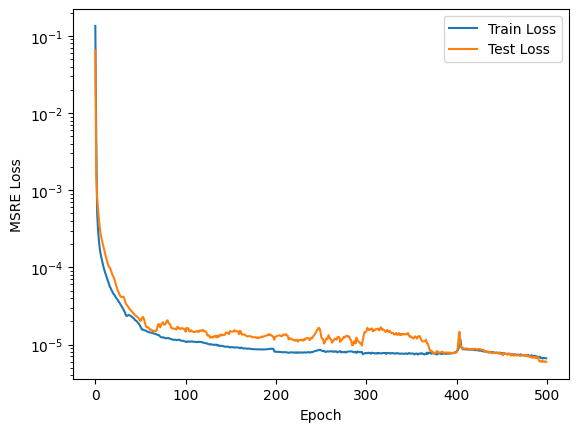

NameError: name 'plot_result' is not defined

In [38]:
#print(tensor_nd_test)

plot_loss(loss_dict_MAEBAPF)
final_result = plot_result(tensor_nd_full, models_MAEBAPF)
final_prediction = predict_bench(tensor_nd_bench, models_MAEBAPF)
#print(final_result)
submission = pd.DataFrame({
    "id": range(len(final_result)),
    "prediction": final_result})
submission ['prediction'] = submission ['prediction'] # x8b
#print(submission['prediction'].to_numpy())
#print(tensor_nd_full['y'].cpu().numpy().flatten())
mape = mape_singular(submission['prediction'].to_numpy(), tensor_nd_full['y'].cpu().numpy().flatten())
print("Mape")
print(mape)

submission = pd.DataFrame({
    "id": range(len(final_prediction)),
    "prediction": final_prediction})
submission ['prediction'] = submission ['prediction'] * x8b

submission.to_csv("predictions.csv", index=False)

print(submission)

# **Assignment 1 MODEL**

In [39]:
data_nh = data_nh.reset_index(drop=True)
data_nh_train_pd = data_nh.sample(frac = 0.8 , random_state=1111,ignore_index=True)
data_nh_train_pd = data_nh_train_pd[['0','1','2','3','4','5','6','7','8','area']]


data_nh_test_pd = data_nh.drop(data_nh_train_pd.index).reset_index(drop=True)
data_nh_test_pd = data_nh_test_pd[['0','1','2','3','4','5','6','7','8','area']]

z = data_nh_train_pd['area']


data_nh_test = data_nh_test_pd.to_numpy()
data_nh_train = data_nh_train_pd.to_numpy()
print(data_nh_train)
print(data_nh_test)

[[0.         0.         0.03423095 ... 1.99474484 3.31273577 0.63561477]
 [0.07710717 0.22707347 0.5161836  ... 1.95223811 3.99121146 1.52274339]
 [0.         0.         0.02504167 ... 2.06347482 3.97365385 1.20831322]
 ...
 [0.04183361 0.10921983 0.31150056 ... 2.1660259  3.93961591 1.62701933]
 [0.         0.         0.49909721 ... 1.97291102 2.70150228 2.33188428]
 [0.         0.         0.11020515 ... 2.19334252 2.53387018 2.21698679]]
[[0.30155698 0.35852096 0.50636153 ... 1.01597955 3.78563402 1.07671808]
 [0.11118279 0.33107138 0.50413445 ... 2.73472647 3.67933127 1.79768075]
 [0.1571817  0.22319407 0.25703798 ... 2.51981336 3.99572172 1.28561748]
 ...
 [0.11779845 0.1258984  0.31859702 ... 2.32285333 2.82305667 2.16978745]
 [0.13649259 0.32361207 0.6249654  ... 1.56424292 3.92795987 1.743879  ]
 [0.0940076  0.10283662 0.24263107 ... 1.21430681 3.5657594  0.87168324]]


In [19]:
#The different way to initilialize the weights
def init_weights_2(input_dim, output_dim, sigma=0.1):
    return np.random.normal(0.0, sigma, (input_dim, output_dim))

In [20]:
# Predict using a trained set of model weights for a 3 hidden layer network
def predict_depth3(input, weights):
    [w1, w2, w3, w4] = weights
    return relu(relu(relu(input @ w1) @ w2) @ w3) @ w4

In [21]:
# Loss functions
def msre(input, target):
    return np.square((target - input) / target).mean()

In [22]:
# Activation functions

def relu(input):
    return np.maximum(0, input)

In [23]:
#D1H Depth 3 Mini Batch

# Function to train a simple 2-N-1 model.
# NOTE: This function expects numpy matrices for the train and test data.
#       If your train and test data is stored in pandas dataframes you 
#       can convert using the `.to_numpy()` function.

def train_model_dh_depth3_mini(
    num_neurons, epochs, train, test, lr = 300e-5, batch_size = 50
):
    w1 = init_weights_2(9, num_neurons)
    w2 = init_weights_2(num_neurons, num_neurons)
    w3 = init_weights_2(num_neurons, num_neurons)
    w4 = init_weights_2(num_neurons, 1)

    train_loss = []
    test_loss = []
    
    wbackup = []

    for epoch in range(epochs):
        epoch_loss = 0
        if not(epoch % (epochs/100)):
            error = []
            
            X = data_nh.iloc[:, :9].to_numpy()
            prediction_test = predict_depth3(X, [w1, w2, w3, w4]) 
            for i in range(len(train)):
                error.append(msre(prediction_test[i], z[i]))
                
            wbackup.append([epoch, sum(error)/len(error), w1, w2, w3, w4])
            print ("epoch:", epoch, "; msre = ", sum(error)/len(error))
        train_index = 0
        train_end = 0
        while (train_end+1 != train.shape[0]):

            train_end = train_index + batch_size
            if(train_end >= train.shape[0]):
                train_end = train.shape[0]-1
                
            batch = train[train_index:train_end]
            train_index += batch_size
            # Split the label from the input
            [x0, y] = np.split(batch, [-1], axis=1)
            #print(x0.shape, w1.shape)
            # Forward pass
            z1 = x0 @ w1
            x1 = relu(z1)

            z2 = x1 @ w2
            x2 = relu(z2)
            
            z3 = x2 @ w3
            x3 = relu(z3)

            z4 = x3 @ w4

            # Compute error
            loss = msre(z4, y)
            epoch_loss += loss

            # TODO: Implement backward pass.
            N = z4.size
            
            dz4 = (2.0 / N) * (z4-y) / (y * y)
            
            dw4 = x3.T @ dz4

            dx3 = dz4 @ w4.T
            dz3 = dx3 * (z3 > 0)
            dw3 = x2.T @ dz3
            
            dx2 = dz3 @ w3.T
            dz2 = dx2 * (z2 > 0)   
            dw2 = x1.T @ dz2                       # (num_neurons, 1)
            
            dx1 = dz2 @ w2.T                       # (1, num_neurons)
            dz1 = dx1 * (z1 > 0)                   # ReLU derivative
            dw1 = x0.T @ dz1                       # (2, num_neurons)

            w4 = w4 - lr * dw4
            w3 = w3 - lr * dw3
            w2 = w2 - lr * dw2
            w1 = w1 - lr * dw1

        #TODO: Compute total loss for the epoch
        loss_this_epoch = epoch_loss / len(train) # Replace nan with your code
        # Add the loss for this epoch to the list of losses
        train_loss.append(loss_this_epoch)
        
        # Compute and store test loss.
        pred = predict_depth3(test[:, :9], [w1, w2, w3, w4])
        test_loss.append(msre(pred[:, 0], test[:, 9]))

    return [[train_loss, test_loss], [w1, w2, w3, w4]]

In [24]:
#Model Train - Depth 3 D1H MINI BATCH

#MSRE = 0.00038 with epochs = 150, neurons = 100, lr = 315e-5 (no mini batch)
#MSRE = 0.00011 with epochs = 300, neurons = 100, lr = 310e-5 (no mini batch)
#MSRE = 0.00005 with epochs = 10000, neurons = 64, lr = 1000e-5, batch_size = 50
#MSRE = 0.000014 with epochs = 20000, neurons = 64, lr = 1000e-5, batch_size = 50
#MSRE = 0.00000737 = 7*10^-6 with epochs = 30000, neurons = 64, lr = 1000e-5, batch_size = 50
epochs = 200
[[trainloss_dh, testloss_dh], [w1_dh, w2_dh, w3_dh, w4_dh]] = train_model_dh_depth3_mini(140, epochs, data_nh_train, data_nh_test, lr = 0.1e-3, batch_size = 40)

epoch: 0 ; msre =  64808.47593553604
epoch: 2 ; msre =  4436784.141425953
epoch: 4 ; msre =  5201795.135530006
epoch: 6 ; msre =  5845795.954808877
epoch: 8 ; msre =  6558207.834451126
epoch: 10 ; msre =  7262346.495514188
epoch: 12 ; msre =  7952050.519983061
epoch: 14 ; msre =  8670664.349814277
epoch: 16 ; msre =  9376604.506762005
epoch: 18 ; msre =  10064236.695816047
epoch: 20 ; msre =  10763335.256176498
epoch: 22 ; msre =  11502420.67514247
epoch: 24 ; msre =  12248768.083454099
epoch: 26 ; msre =  12995104.089977153
epoch: 28 ; msre =  13763215.563325765
epoch: 30 ; msre =  14522214.705113983
epoch: 32 ; msre =  15273790.629841426
epoch: 34 ; msre =  16041792.013139142
epoch: 36 ; msre =  16819387.27994764
epoch: 38 ; msre =  17589206.335859332
epoch: 40 ; msre =  18349921.166369893
epoch: 42 ; msre =  19104342.249918636
epoch: 44 ; msre =  19856140.483214498
epoch: 46 ; msre =  20595482.87399765
epoch: 48 ; msre =  21305799.71009625
epoch: 50 ; msre =  21990827.923732184
epoc

KeyboardInterrupt: 

In [ ]:
#Predict Depth 3 d1H
def predict_all(data, weights):
    X = data.iloc[:, :9].to_numpy()    #convert pd df to numpy       
    return predict_depth3(X, weights)   
prediction_dh = predict_all(data_nh_bench, [w1_dh, w2_dh, w3_dh, w4_dh])
prediction_test = predict_all(data_nh_train_pd, [w1_dh, w2_dh, w3_dh, w4_dh])

model_test = pd.DataFrame({
    "id": range(len(data_nh_train_pd)),
    "prediction": prediction_test.ravel()
})
'''
submission = pd.DataFrame({
    "id": range(len(data_bench_dh)),
    "prediction": prediction_dh.ravel()
})

submission.to_csv("predictions.csv", index=False)
'''
error = []
for i in range(12000):
    error.append(msre(prediction_test[i], z[i]))

print (sum(error)/len(error))

mape2 = mape_singular(model_test['prediction'].to_numpy(), z)
print (mape2)

In [ ]:
#Train vs Test Loss Plot

epochs = np.arange(len(trainloss_dh))

plt.plot(epochs, trainloss_dh, label="Train Loss")
plt.plot(epochs, testloss_dh, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("MSRE Loss")
plt.yscale("log")
plt.legend()

fig1 = plt.gcf()
plt.show()


#fig1.savefig('loss.jpg', format='jpg')